In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import pyagrum as gum
import pyagrum.lib.notebook as gnb
from IPython.display import display, HTML
import warnings
from tqdm import tqdm

sys.path.insert(0, str(Path().resolve().parents[1]))
from src.config import *  # noqa
from src.utils import *  # noqa
from src.mosaic import *  # noqa

In [2]:
# Read config file
config = load_config("conf_local.yaml")

# Results folder: a single one for the whole hyperparameter grid (see
# exp_local.py); each row of df_tot.csv already carries its own
# n_clients/ess/prob_shift/alpha combination.
res_path = Path(config["res_path"])

# Read results (all weighting schemas x all grid combinations, one row per
# (n_clients, ess, prob_shift, alpha, size, rep))
df_tot = pd.read_csv(res_path / f"df_tot.csv")

In [3]:
# Per-repetition (raw df_tot row) derived quantities, computed BEFORE
# aggregating across repetitions: relative gain of each MOSAIC schema over
# plain IDM, on mean JSD (positive = MOSAIC closer to the ground truth than
# IDM alone).
GAIN_COLS = [f"gain_w{w}" for w in (2, 3)]
for w in (2, 3):
    df_tot[f"gain_w{w}"] = (
        df_tot["idm_mean"] - df_tot[f"mos_w{w}_mean"]
    ) / df_tot["idm_mean"]

CONTAIN_COLS = ["idm_gt_contained"] + [f"mos_w{w}_gt_contained" for w in (2, 3)]
JSD_MEAN_COLS = ["mle", "idm_mean"] + [f"mos_w{w}_mean" for w in (2, 3)]

# Mean across repetitions, grouped by every grid hyperparameter AND size
# (not just size, otherwise different hyperparameter combinations would
# be silently averaged together). Covers every JSD statistic, including
# idm_max/mos_w_max: Grafico 1 below plots mean-to-max directly from
# these columns (see that cell for why min is no longer plotted, even
# though it is still computed and available here).
group_cols = ["n_clients", "ess", "prob_shift", "alpha", "size"]
df_mean = df_tot.drop(columns="rep").groupby(group_cols, as_index=False).mean()

# For the two DERIVED per-repetition quantities (gain, containment), we
# additionally want the standard deviation ACROSS repetitions, i.e. how
# much the ESTIMATE of the mean itself would vary if the whole experiment
# were repeated, which is a different question from "how wide is a single
# credal set" (already shown by Grafico 1's mean-to-max band). Computed on
# the SAME per-repetition values grouped above, so mean and std are always
# a matched pair.
df_gain_std = df_tot.groupby(group_cols, as_index=False)[GAIN_COLS].std()
df_gain_std = df_gain_std.rename(columns={c: f"{c}_std" for c in GAIN_COLS})
df_contain_std = df_tot.groupby(group_cols, as_index=False)[CONTAIN_COLS].std()
df_contain_std = df_contain_std.rename(columns={c: f"{c}_std" for c in CONTAIN_COLS})
df_jsd_std = df_tot.groupby(group_cols, as_index=False)[JSD_MEAN_COLS].std()
df_jsd_std = df_jsd_std.rename(columns={c: f"{c}_std" for c in JSD_MEAN_COLS})

df_mean = (
    df_mean.merge(df_gain_std, on=group_cols)
    .merge(df_contain_std, on=group_cols)
    .merge(df_jsd_std, on=group_cols)
)

# The intersection ratio gets its own MEDIAN (not mean) plus Q1/Q3: Q1 <=
# median <= Q3 always holds by construction, but NOT for the mean when the
# distribution is skewed (intersection_frac piles up near 1.0 with an
# occasional low outlier rep, which pulls the mean below Q1, verified on
# real data). Pairing the mean with an IQR band would be a mismatched pair
# of statistics; median+IQR is the consistent, non-parametric choice (and
# mirrors PriorCN.compute, which already summarizes each repetition via a
# median across mechanisms).
df_mean["intersection_frac_median"] = (
    df_tot.groupby(group_cols)["intersection_frac"].median().to_numpy()
)
df_mean["intersection_frac_q1"] = (
    df_tot.groupby(group_cols)["intersection_frac"].quantile(0.25).to_numpy()
)
df_mean["intersection_frac_q3"] = (
    df_tot.groupby(group_cols)["intersection_frac"].quantile(0.75).to_numpy()
)
# df_mean.head()

In [4]:
sns.reset_defaults()
plt.style.use("seaborn-v0_8-paper")

plt.rcParams.update(
    {
        # ---- base ----
        "figure.figsize": [7, 4],
        "font.size": 9,
        # ---- axes ----
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "axes.linewidth": 0.8,
        "axes.edgecolor": "black",
        # ---- legend ----
        "legend.fontsize": 10,
        # "legend.labelspacing": 0.3,
        # ---- ticks ----
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        # ---- lines ----
        "lines.linewidth": 1.0,
        # ---- dpi ----
        "figure.dpi": 300,
        "savefig.dpi": 300,
        # # ---- tex ----
        "text.usetex": True,
    }
)

# Per-subplot size (inches), shared by every hyperparameter-grid plot below;
# the total figure size is this times the grid's row/column count. Same
# values as plot_global.ipynb, kept here as plain constants to tweak by hand.
SUBPLOT_WIDTH = 4.5
SUBPLOT_HEIGHT = 3.2

# Across-repetition uncertainty is shown as sparse dot-whisker markers on
# the mean/median line, not as a second overlapping fill_between band (a
# continuous band stays reserved for Grafico 1's mean-to-max credal-set
# width, which is a different kind of spread, not a repetition statistic).
N_WHISKER_MARKERS = 6  # how many markers per curve
WHISKER_DODGE = 8  # horizontal offset (in N units) between methods' markers

# Global knobs for every plot below: one line width for all curves
# (solid method lines and dashed references alike), one for the whisker
# markers' error bars (including their caps).
CURVE_LINEWIDTH = 1.0
WHISKER_LINEWIDTH = 1.0


def add_std_whiskers(ax, x, y, err, color, dodge=0.0, n_markers=N_WHISKER_MARKERS, clip_lower=None):
    """
    Sparse dot-whisker markers for the across-repetition spread around a
    mean/median line. `err` is either a symmetric half-width (e.g. std) or
    an (lower_half, upper_half) pair of arrays for an asymmetric interval
    (e.g. an IQR). `clip_lower` floors the lower whisker (e.g. for a
    log-scale axis, where a non-positive bound would be invalid).
    """
    x, y = np.asarray(x), np.asarray(y)
    idx = np.linspace(0, len(x) - 1, n_markers).astype(int)
    wx, wy = x[idx] + dodge, y[idx]
    if isinstance(err, tuple):
        lo_half, hi_half = np.asarray(err[0])[idx], np.asarray(err[1])[idx]
    else:
        lo_half = hi_half = np.asarray(err)[idx]
    lo, hi = wy - lo_half, wy + hi_half
    if clip_lower is not None:
        lo = np.clip(lo, clip_lower, None)
    ax.errorbar(
        wx, wy, yerr=[wy - lo, hi - wy], fmt="o", color=color, markersize=3,
        markeredgecolor="white", markeredgewidth=0.4,
        elinewidth=WHISKER_LINEWIDTH, capsize=2.5, capthick=WHISKER_LINEWIDTH, zorder=5,
    )

In [5]:
# Facet grid: rows = (n_clients, ess) combinations, columns =
# (prob_shift, alpha) combinations.
row_vals = sorted(set(df_mean[["n_clients", "ess"]].itertuples(index=False, name=None)))
col_vals = sorted(
    set(df_mean[["prob_shift", "alpha"]].itertuples(index=False, name=None)),
    key=lambda pa: (pa[0], -pa[1]),
)
print(
    f"Grid: {len(row_vals)} row(s) (n_clients, ess) x {len(col_vals)} col(s) (prob_shift, alpha)"
)


def row_label(nc, ess):
    return fr"$S={ess}$"


def col_label(p, a):
    # alpha is irrelevant (and deduplicated away, see exp_local.hyperparameter_combos)
    # whenever prob_shift == 0.0.
    return fr"$\rho={p}$" if p == 0 else fr"$\rho={p}$, $\alpha={a}$"


Grid: 4 row(s) (n_clients, ess) x 3 col(s) (prob_shift, alpha)


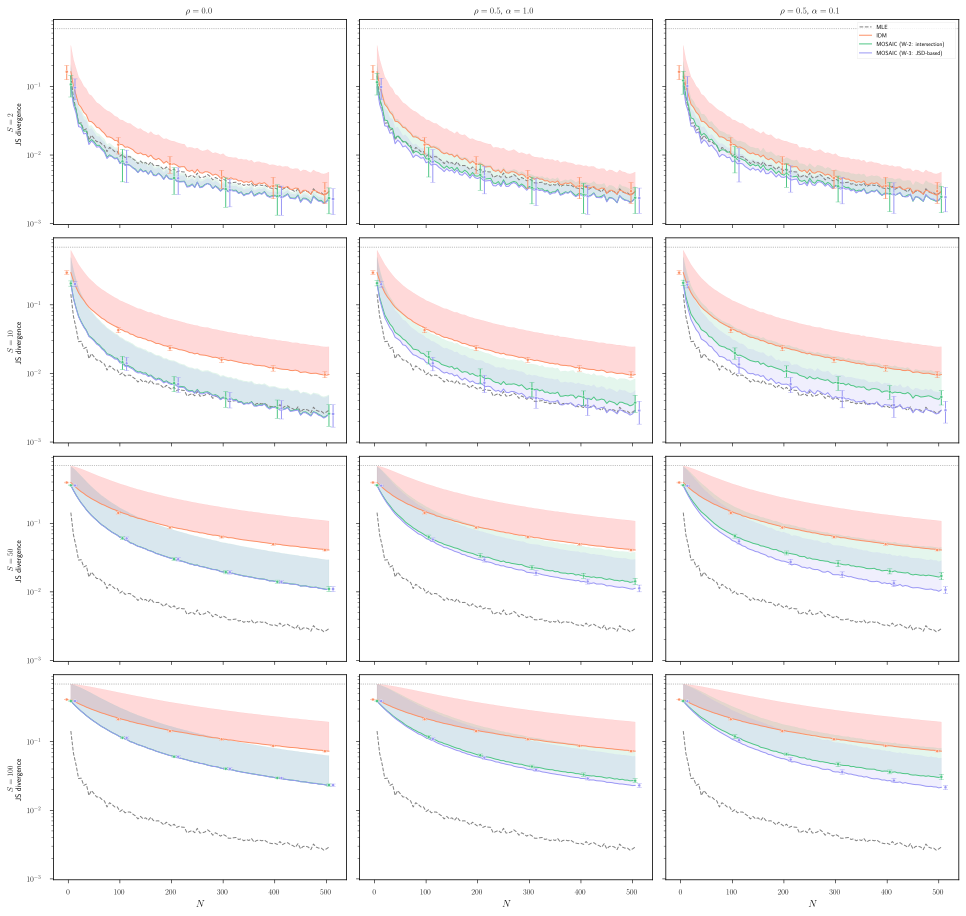

In [6]:
# Grafico 1: one panel per (n_clients, ess) x (prob_shift, alpha)
# combination. Mean-to-max band (NOT min-to-max): the max is exact (vertex
# enumeration, since JSD is convex in its second argument) and already
# conveys the credal set's worst case; the minimum is the weakest, most
# easily-gamed evidence for "MOSAIC is good" (a wider, less informative
# credal set trivially achieves a lower minimum just by having more
# volume, not because it is a better estimate), so it is intentionally not
# plotted here, even though it is still computed and saved in df_tot.csv.
mos_colors = {2: "#4fc685", 3: "#9a97f4"}
mos_labels = {
    2: "MOSAIC (W-2: intersection)",
    3: "MOSAIC (W-3: JSD-based)",
}

fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(SUBPLOT_WIDTH * len(col_vals), SUBPLOT_HEIGHT * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for i, (nc, ess) in enumerate(row_vals):
    for j, (p, a) in enumerate(col_vals):
        ax = axes[i][j]
        sub = df_mean[
            (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
            & (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
        ].sort_values("size")

        ax.plot(
            sub["size"], sub["mle"], "--", linewidth=CURVE_LINEWIDTH, color="grey", label="MLE"
        )
        # Uncomment to also show MLE's own repetition variability:
        # add_std_whiskers(ax, sub["size"], sub["mle"], sub["mle_std"], color="grey", dodge=2 * WHISKER_DODGE, clip_lower=1e-6)

        ax.fill_between(
            sub["size"], sub["idm_mean"], sub["idm_max"], color="red", alpha=0.15
        )
        ax.plot(sub["size"], sub["idm_mean"], "-", color="#fc9167", linewidth=CURVE_LINEWIDTH, label="IDM")
        add_std_whiskers(
            ax, sub["size"], sub["idm_mean"], sub["idm_mean_std"], color="#fc9167",
            dodge=-WHISKER_DODGE, clip_lower=1e-6,
        )
        for k, (w, color) in enumerate(mos_colors.items()):
            ax.fill_between(
                sub["size"],
                sub[f"mos_w{w}_mean"],
                sub[f"mos_w{w}_max"],
                color=color,
                alpha=0.15,
            )
            ax.plot(sub["size"], sub[f"mos_w{w}_mean"], color=color, linewidth=CURVE_LINEWIDTH, label=mos_labels[w])
            add_std_whiskers(
                ax, sub["size"], sub[f"mos_w{w}_mean"], sub[f"mos_w{w}_mean_std"],
                color=color, dodge=k * WHISKER_DODGE, clip_lower=1e-6,
            )

        ax.set_yscale("log")
        # Theoretical max JSD (nats): src/utils.py's jsd() uses np.log, so
        # the [0, ln(2)] bound applies, not [0, 1] (that would be the
        # log2 convention). 0 itself cannot be drawn on this log-scale axis.
        ax.axhline(np.log(2), color="gray", linewidth=0.7, linestyle=":")
        if i == 0:
            ax.set_title(col_label(p, a), fontsize=9)
        if j == 0:
            ax.set_ylabel(
                f"{row_label(nc, ess)}\nJS divergence", fontsize=8
            )
        if i == len(row_vals) - 1:
            ax.set_xlabel("$N$")

axes[0][-1].legend(loc="upper right", fontsize=6)

plt.tight_layout()
plt.show()

# Save figure
fig.savefig(f"{res_path}.svg", dpi=1200, bbox_inches="tight", transparent=False)

In [7]:
# # Plot: intersection ratio, one panel per grid combination. Meaningful for
# # weighting=2 (hard intersection); computed and available for all schemas
# # since it only depends on the target/candidates' own credal sets, not on
# # the weighting formula (see exp_local.py).
# fig, axes = plt.subplots(
#     len(row_vals),
#     len(col_vals),
#     figsize=(SUBPLOT_WIDTH * len(col_vals), SUBPLOT_HEIGHT * len(row_vals)),
#     squeeze=False,
#     sharex=True,
#     sharey=True,
# )

# for i, (nc, ess) in enumerate(row_vals):
#     for j, (p, a) in enumerate(col_vals):
#         ax = axes[i][j]
#         sub = df_mean[
#             (df_mean["prob_shift"] == p)
#             & (df_mean["alpha"] == a)
#             & (df_mean["n_clients"] == nc)
#             & (df_mean["ess"] == ess)
#         ].sort_values("size")

#         ax.plot(
#             sub["size"], sub["intersection_frac_median"], color="green", linewidth=CURVE_LINEWIDTH, label="Median"
#         )
#         add_std_whiskers(
#             ax, sub["size"], sub["intersection_frac_median"],
#             (
#                 sub["intersection_frac_median"] - sub["intersection_frac_q1"],
#                 sub["intersection_frac_q3"] - sub["intersection_frac_median"],
#             ),
#             color="green",
#         )

#         if i == 0:
#             ax.set_title(col_label(p, a), fontsize=9)
#         if j == 0:
#             ax.set_ylabel(
#                 f"{row_label(nc, ess)}\nC-set intersection ratio", fontsize=8
#             )
#         if i == len(row_vals) - 1:
#             ax.set_xlabel("$N$")

# axes[0][-1].legend(loc="upper right", fontsize=6)

# plt.tight_layout()
# plt.show()

# # Save figure
# fig.savefig(
#     f"{res_path}_intersection.svg", dpi=1200, bbox_inches="tight", transparent=False
# )

## Grafico 1.1: relative gain of each weighting schema over IDM

$\text{gain}_w = (\text{JSD}_{\text{IDM,mean}} - \text{JSD}_{\text{MOSAIC-}w\text{,mean}}) / \text{JSD}_{\text{IDM,mean}}$, computed per repetition, then averaged. Positive = MOSAIC closer to the ground truth than plain local IDM. The band is mean $\pm$ 1 standard deviation **across repetitions** (how reproducible the gain is if the whole experiment were repeated), not a measure of how wide a single credal set is (that's Grafico 1's mean-to-max band).

In [8]:
# fig, axes = plt.subplots(
#     len(row_vals),
#     len(col_vals),
#     figsize=(SUBPLOT_WIDTH * len(col_vals), SUBPLOT_HEIGHT * len(row_vals)),
#     squeeze=False,
#     sharex=True,
#     sharey=True,
# )

# for i, (nc, ess) in enumerate(row_vals):
#     for j, (p, a) in enumerate(col_vals):
#         ax = axes[i][j]
#         sub = df_mean[
#             (df_mean["prob_shift"] == p)
#             & (df_mean["alpha"] == a)
#             & (df_mean["n_clients"] == nc)
#             & (df_mean["ess"] == ess)
#         ].sort_values("size")

#         ax.axhline(0.0, color="gray", linewidth=0.7, linestyle=":")
#         for k, (w, color) in enumerate(mos_colors.items()):
#             m = sub[f"gain_w{w}"]
#             s = sub[f"gain_w{w}_std"]
#             ax.plot(sub["size"], m, color=color, linewidth=CURVE_LINEWIDTH, label=mos_labels[w])
#             dodge = (k - 0.5) * WHISKER_DODGE
#             add_std_whiskers(ax, sub["size"], m, s, color=color, dodge=dodge)

#         if i == 0:
#             ax.set_title(col_label(p, a), fontsize=9)
#         if j == 0:
#             ax.set_ylabel(f"{row_label(nc, ess)}\nRelative gain vs IDM", fontsize=8)
#         if i == len(row_vals) - 1:
#             ax.set_xlabel("$N$")

# axes[0][-1].legend(loc="upper right", fontsize=6)

# plt.tight_layout()
# plt.show()

# fig.savefig(f"{res_path}_gain.svg", dpi=1200, bbox_inches="tight", transparent=False)

## Grafico 1.2: ground-truth containment ratio

Fraction of CPT entries across the network where the TRUE (ground-truth) parameters are actually contained in the credal set (`gt_containment_frac`, `src/utils.py`): the empirical check of "Reliability of credal sets" (`cap6_extract.tex`, Definition `as:credal`). Unlike $\widehat{\theta}^e$ (the MLE, always inside the local IDM credal set for any ess, an algebraic fact, see `exp_local.py`), containment of the true, unknown parameters is **not** guaranteed. This is expected to be MOSAIC's "negative" result: a narrower, more precise credal set can come at the cost of lower containment than IDM alone. Same mean $\pm$ std-across-repetitions band as Grafico 1.1.

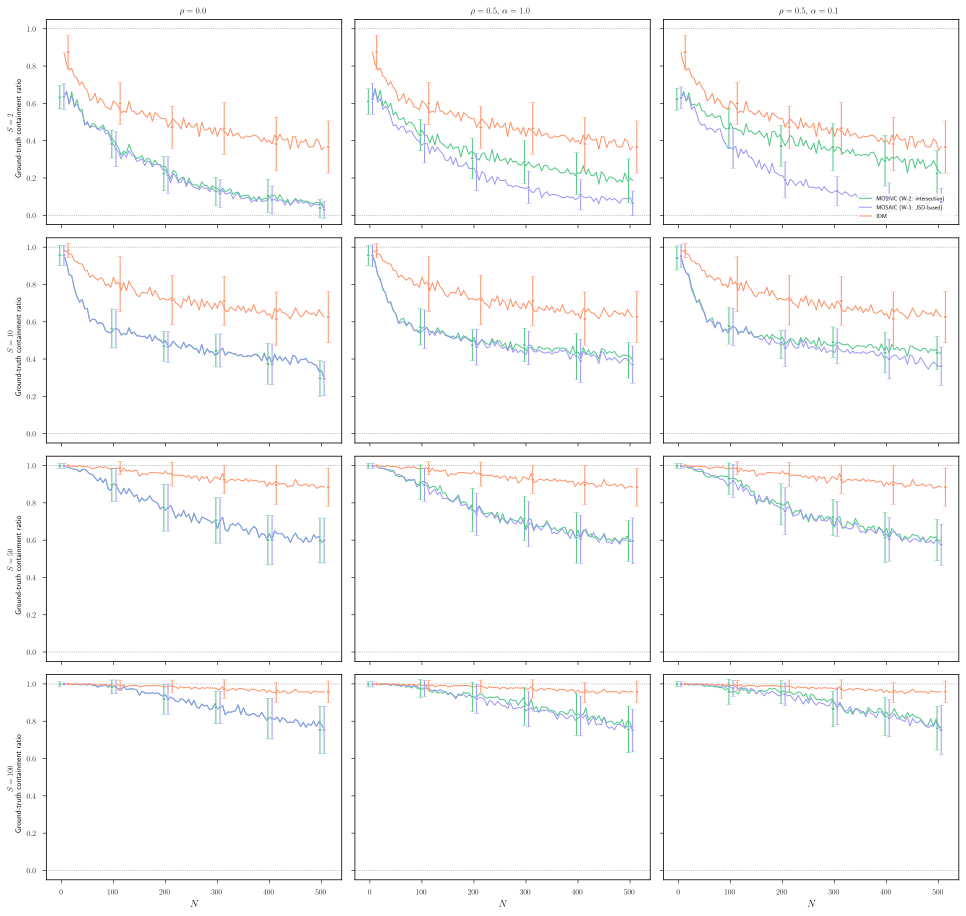

In [9]:
contain_colors = dict(mos_colors)
contain_colors["idm"] = "#fc9167"
contain_labels = dict(mos_labels)
contain_labels["idm"] = "IDM"

fig, axes = plt.subplots(
    len(row_vals),
    len(col_vals),
    figsize=(SUBPLOT_WIDTH * len(col_vals), SUBPLOT_HEIGHT * len(row_vals)),
    squeeze=False,
    sharex=True,
    sharey=True,
)

for i, (nc, ess) in enumerate(row_vals):
    for j, (p, a) in enumerate(col_vals):
        ax = axes[i][j]
        sub = df_mean[
            (df_mean["prob_shift"] == p)
            & (df_mean["alpha"] == a)
            & (df_mean["n_clients"] == nc)
            & (df_mean["ess"] == ess)
        ].sort_values("size")

        ax.axhline(0.0, color="gray", linewidth=0.7, linestyle=":")
        ax.axhline(1.0, color="gray", linewidth=0.7, linestyle=":")
        for k, (kind, color) in enumerate(contain_colors.items()):
            prefix = "idm_gt_contained" if kind == "idm" else f"mos_w{kind}_gt_contained"
            m = sub[prefix]
            s = sub[f"{prefix}_std"]
            ax.plot(sub["size"], m, color=color, linewidth=CURVE_LINEWIDTH, label=contain_labels[kind])
            dodge = (k - (len(contain_colors) - 1) / 2) * WHISKER_DODGE
            add_std_whiskers(ax, sub["size"], m, s, color=color, dodge=dodge)

        ax.set_ylim(-0.05, 1.05)
        if i == 0:
            ax.set_title(col_label(p, a), fontsize=9)
        if j == 0:
            ax.set_ylabel(f"{row_label(nc, ess)}\nGround-truth containment ratio", fontsize=8)
        if i == len(row_vals) - 1:
            ax.set_xlabel("$N$")

axes[0][-1].legend(loc="lower right", fontsize=6)

plt.tight_layout()
plt.show()

fig.savefig(f"{res_path}_containment.svg", dpi=1200, bbox_inches="tight", transparent=False)

## Loading a saved model (`results/models/<task_id>.pkl`)

Reference example for reading back a model saved by `exp_local.py`. The global optimization phase (`exp_global.py`, `plot_global.ipynb`) reads its own saved models the same way, one client's worth of keys at a time. **Always go through `lookup_cpt_row`**, never `cpt.topandas()` or a hand-rolled row index (see `snapshot_cpts`/`lookup_cpt_row` in `src/utils.py` for why).

Models are archived **one file per task** (`results/models/<n_clients>_<ess>_<prob_shift>_<alpha>_<size>_<rep>.pkl`, see `exp_local.py`'s `_model_filename`) instead of a single `models.pkl` for the whole grid. Saving is off by default (`save_models: false` in `conf_local.yaml`) since it slows down a plain sweep; this demo only works when a run had `save_models: true`.

In [10]:
import pickle
from src.utils import lookup_cpt_row

models_dir = res_path / "models"
model_files = sorted(models_dir.glob("*.pkl"))
print(f"{len(model_files)} saved models found in {models_dir}")

# The filename itself IS the task_id (n_clients, ess, prob_shift, alpha, size, rep).
model_path = model_files[0]
print(
    "Example task_id (n_clients, ess, prob_shift, alpha, size, rep):", model_path.stem
)

with open(model_path, "rb") as f:
    model = pickle.load(f)
print("Available model kinds:", sorted(model.keys()))

# Read P(Cancer | Pollution, Smoker) from client 0's MOSAIC-updated credal
# set (weighting=3, lower bound), for one specific parent configuration.
entry = model["mos_w3_min"]["C"]
print("\nC's parent configurations (row order):", entry["parents"])
print("C's own category labels (column order):", entry["labels"])

row = lookup_cpt_row(entry, parents={"P": "low", "S": "True"})
print(
    "\nP(C | P=low, S=True)  [MOSAIC w3, lower bound] =",
    dict(zip(entry["labels"], row)),
)

# A root variable (no parents) is read the same way, with parents=None.
entry_p = model["bn_mle"]["P"]
print(
    "P(Pollution)  [client 0's exact MLE] =",
    dict(zip(entry_p["labels"], lookup_cpt_row(entry_p))),
)

0 saved models found in results_local/models


IndexError: list index out of range